# Pro player cohorts, part 4: regional distribution, by title and community

**Purpose**: fourth notebook in the pro-cohort thread. Parts 1-3 found
C1 oldest/longest-careered/lowest-churn, C0 highest-churn, and C0/C1
tied (both high) on earnings concentration with C2 distinctly lower --
and a genuinely null cross-check between pro-earnings concentration and
audience-attention concentration. This one asks: does a community's
*pro talent pool* concentrate regionally the same way its audience
does, or differently? Same scope as parts 1-3: C0/C1/C2, C3 excluded.

**A real scheme-asymmetry to flag up front, not bury in caveats.**
`players_lpdb.region` (this notebook's source, nationality-based) and
the audience-side `dominant_audience_region` reference
(`creator_crossover_community_detection.ipynb`, language-based, from
`language_mix_snapshots`) use *differently shaped* region sets. The
audience scheme deliberately excludes English, Spanish, Chinese, and
Arabic speakers as too ambiguous to place on one region -- which makes
North America, and most of Latin America and MENA, **structurally
invisible** as a dominant audience region, by construction, not because
those audiences don't exist. The pro-side nationality scheme has no such
gap -- North America, Africa, and Oceania all show up as real,
nameable categories here. **A title/community showing North America as
its dominant pro region but something else as its dominant audience
region is not necessarily a real pro/audience divergence** -- it may
just be this scheme asymmetry. Checked and flagged per-case below, not
treated as uniformly meaningful.

In [1]:
import sys
import re
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from etl.db import get_connection

COMMUNITY_TITLE_LISTS = {
    "C0": ["apex_legends", "fortnite", "league_of_legends", "overwatch", "rainbow_six_siege", "rocket_league", "teamfight_tactics", "valorant"],
    "C1": ["age_of_empires_ii", "counter_strike", "dota2", "hearthstone", "pubg", "starcraft2"],
    "C2": ["brawl_stars", "free_fire", "mobile_legends_bb", "pubg_mobile", "wild_rift"],
    "C3": ["guilty_gear", "mortal_kombat", "street_fighter", "tekken"],
}
community_by_title = {t: c for c, titles in COMMUNITY_TITLE_LISTS.items() for t in titles}
in_scope_titles = [t for t in community_by_title if community_by_title[t] != "C3"]

import yaml
with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]
display_name_by_id = {t["id"]: t["display_name"] for t in titles_config if t.get("is_active")}

colors = {"C0": "#C44E52", "C1": "#4C72B0", "C2": "#55A868"}
order = ["C1", "C0", "C2"]

## Clean and bucket `players_lpdb.region` -- checked live before trusting it

Raw values are free-text wiki data: inconsistent casing, a handful of
literal un-stripped `<span class="flag">...</span>` wikitext fragments,
and over-granular splits (`Asia-Pacific` / `Asia-Pacific South` /
`Asia-Pacific North` / `asia pacific asia`) that need collapsing to be
usable. Mapped to the **same 5 macro-regions** used by the audience-side
reference (CIS, Asia-Pacific, Europe, Latin America, MENA), plus 3 more
the pro side can actually see (North America, Africa, Oceania) that the
audience scheme structurally cannot (see intro).

In [2]:
conn = get_connection()
players = pd.DataFrame(conn.execute(
    "SELECT title_id, region FROM players_lpdb"
).fetchall(), columns=["title_id", "region"])
conn.close()
players = players[players["title_id"].isin(in_scope_titles)]
players["community"] = players["title_id"].map(community_by_title)

def clean_region(raw):
    s = re.sub(r"<[^>]+>", "", raw or "").strip().lower()
    return s

players["region_clean"] = players["region"].map(clean_region)

REGION_TO_MACRO = {
    "cis": "CIS",
    "southeast asia": "Asia-Pacific", "asia": "Asia-Pacific", "east asia": "Asia-Pacific",
    "south korea": "Asia-Pacific", "china": "Asia-Pacific", "south asia": "Asia-Pacific",
    "asia-pacific": "Asia-Pacific", "asia-pacific south": "Asia-Pacific", "asia-pacific north": "Asia-Pacific",
    "northeast asia": "Asia-Pacific", "pacific": "Asia-Pacific", "korea": "Asia-Pacific",
    "japan": "Asia-Pacific", "asia pacific asia": "Asia-Pacific",
    "europe": "Europe", "western europe": "Europe", "balkan": "Europe", "nordic": "Europe",
    "southern europe": "Europe", "united kingdom": "Europe", "turkey": "Europe",
    "south america": "Latin America", "brazil": "Latin America", "latin america south": "Latin America",
    "latin america north": "Latin America", "latin america": "Latin America", "latam": "Latin America",
    "middle east": "MENA", "mea": "MENA", "mena": "MENA", "north africa": "MENA",
    "middle east africa": "MENA",
    "north america": "North America",
    "africa": "Africa", "sub-saharan africa": "Africa",
    "oceania": "Oceania",
}
players["macro_region"] = players["region_clean"].map(REGION_TO_MACRO)

unmapped = players[players["macro_region"].isna() & (players["region_clean"] != "")]
print("Unmapped non-blank values (checked, not silently dropped):")
print(unmapped["region_clean"].value_counts())
print(f"\n{players['macro_region'].notna().sum():,} of {len(players):,} players mapped to a macro-region ({players['macro_region'].notna().mean()*100:.1f}%)")
print(f"(blank region: {(players['region_clean']=='').sum():,}; unmapped-but-nonblank: {len(unmapped):,})")

Unmapped non-blank values (checked, not silently dropped):
region_clean
emea                                                                                          573
asia pacific america                                                                          156
[[file:eu_hd.png|36x24px|europe|link=category:europe]] europe                                   3
[[file:usca hd.png|36x24px|north america|link=category:north america]] north america            2
americas                                                                                        2
[[file:middle east flag hd.png|36x24px|middle east|link=category:middle east]] middle east      1
[[file:african union hd.png|36x24px|africa|link=category:africa]] sub-saharan africa            1
Name: count, dtype: int64

50,331 of 53,735 players mapped to a macro-region (93.7%)
(blank region: 2,666; unmapped-but-nonblank: 738)


## Dominant region, diversity, and concentration per title

`top_region_share` = % of a title's region-mapped pros from its single
most common macro-region. `region_entropy` (Shannon entropy over the
macro-region shares, base 2) is the diversity complement -- higher means
more evenly spread across regions, not concentrated in one.

In [3]:
mapped = players[players["macro_region"].notna()]

rows = []
for title_id, g in mapped.groupby("title_id"):
    shares = g["macro_region"].value_counts(normalize=True)
    entropy = -(shares * np.log2(shares)).sum()
    rows.append({
        "title_id": title_id, "title": display_name_by_id[title_id], "community": community_by_title[title_id],
        "n_mapped": len(g), "dominant_region": shares.idxmax(), "top_region_share": shares.max() * 100,
        "region_entropy": entropy,
    })
region_df = pd.DataFrame(rows).sort_values(["community", "region_entropy"])
region_df.round(2)

,title_id,title,community,n_mapped,dominant_region,top_region_share,region_entropy
1,apex_legends,Apex Legends,C0,1827,Asia-Pacific,53.31,1.55
15,teamfight_tactics,Teamfight Tactics,C0,1183,Asia-Pacific,46.91,2.07
8,league_of_legends,League of Legends,C0,5882,Asia-Pacific,36.18,2.13
10,overwatch,Overwatch,C0,4197,Asia-Pacific,40.24,2.17
14,rocket_league,Rocket League,C0,3554,Europe,34.78,2.39
13,rainbow_six_siege,Rainbow Six Siege,C0,3474,Europe,30.05,2.40
16,valorant,VALORANT,C0,5594,Europe,31.53,2.41
5,fortnite,Fortnite,C0,5711,North America,32.62,2.42
7,hearthstone,Hearthstone,C1,1146,Europe,41.88,2.07
11,pubg,PUBG: BATTLEGROUNDS,C1,1348,Asia-Pacific,47.26,2.08


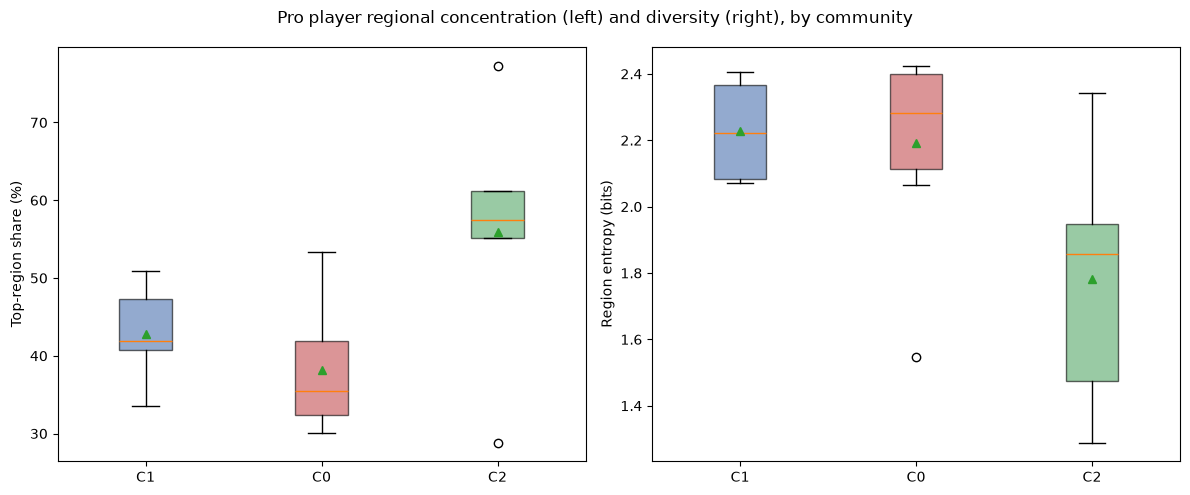

top_region_share                                                   \
                     count   mean    std    min    25%    50%    75%    max   
community                                                                     
C0                     8.0  38.20   8.16  30.05  32.35  35.48  41.91  53.31   
C1                     5.0  42.85   6.64  33.53  40.71  41.88  47.26  50.89   
C2                     5.0  55.98  17.47  28.84  55.10  57.49  61.17  77.29   

          region_entropy                                            
                   count  mean   std   min   25%   50%   75%   max  
community                                                           
C0                   8.0  2.19  0.30  1.55  2.11  2.28  2.40  2.42  
C1                   5.0  2.23  0.15  2.07  2.08  2.22  2.37  2.40  
C2                   5.0  1.78  0.41  1.29  1.47  1.86  1.95  2.34

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric, ylabel in zip(axes, ["top_region_share", "region_entropy"], ["Top-region share (%)", "Region entropy (bits)"]):
    data = [region_df[region_df["community"] == c][metric] for c in order]
    bp = ax.boxplot(data, tick_labels=order, patch_artist=True, showmeans=True)
    for patch, c in zip(bp["boxes"], order):
        patch.set_facecolor(colors[c])
        patch.set_alpha(0.6)
    ax.set_ylabel(ylabel)
fig.suptitle("Pro player regional concentration (left) and diversity (right), by community")
plt.tight_layout()
plt.savefig(Path.cwd() / "_pro_region_fig1_by_community.png", dpi=150, bbox_inches="tight")
plt.show()

region_df.groupby("community")[["top_region_share", "region_entropy"]].describe().round(2)

### Read -- C2 (mobile) is the regionally concentrated one; C0 and C1 are both globalized and barely distinguishable from each other

**C2 (mobile) stands alone as the regionally concentrated community --
C0 and C1 are both diffuse and close to each other, not separated the
way they were on debut age or churn.** Mean top-region-share: C2 55.98%,
C1 42.85%, C0 38.20%. Mean region entropy (diversity): C1 2.23, C0
2.19 -- essentially tied -- against C2's 1.78. Mobile pro talent really
is concentrated into Asia-Pacific specifically (every one of its 5
titles has Asia-Pacific as its dominant region, 28.8-77.3% share),
consistent with the genre's real-world Southeast Asia/East Asia
popularity base. Neither C0 nor C1 shows this kind of lock-in to one
region.

**This is the fourth axis measured in this thread, and the fourth time a
*different* community has turned out to be the distinctive one** --
C1 on age/tenure/churn-stability, C0 on churn-instability specifically
(but tied with C1 on earnings concentration), and now C2 on regional
concentration. No single community is uniformly "the odd one out" --
each axis reveals a different facet, which is itself worth stating
plainly rather than forcing a single master narrative across all four
notebooks.

**C0's own spread (std 8.16 on top-region-share, nearly double C1's
6.64) means "C0 is diffuse" is less uniform a claim than it looks from
the mean alone** -- Fortnite (32.6% share, North America-dominant) and
Apex Legends (53.3%, Asia-Pacific-dominant) sit at opposite ends of
C0's own range. Read C0's mean as a real but noisier central tendency,
not a tight cluster the way C1's tighter std (6.64) or C2's
higher-but-more-internally-consistent concentration are.

## Secondary check: does the dominant pro region match the dominant audience region?

Audience reference copied directly from `creator_crossover_community_detection.ipynb`'s
own already-computed table (language-based, `language_mix_snapshots`) --
not recomputed here. Read with the scheme-asymmetry caveat from the intro
in mind: a "mismatch" that's actually North America/Africa/Oceania vs.
something else is flagged separately from a real cross-scheme mismatch.

In [5]:
DOMINANT_AUDIENCE_REGION = {
    "mobile_legends_bb": "CIS", "dota2": "CIS", "counter_strike": "CIS", "pubg_mobile": "CIS",
    "pubg": "CIS", "wild_rift": "Latin America", "apex_legends": "Asia-Pacific", "brawl_stars": "Europe",
    "teamfight_tactics": "Europe", "hearthstone": "CIS", "valorant": "Europe", "league_of_legends": "Europe",
    "rocket_league": "Europe", "free_fire": "Latin America", "fortnite": "Europe", "overwatch": "Asia-Pacific",
    "starcraft2": "Europe", "rainbow_six_siege": "Europe", "age_of_empires_ii": "Europe",
}
AUDIENCE_COVERAGE_PCT = {
    "mobile_legends_bb": 93.3, "dota2": 82.3, "counter_strike": 77.6, "pubg_mobile": 69.7, "pubg": 67.6,
    "wild_rift": 66.9, "apex_legends": 56.3, "brawl_stars": 54.7, "teamfight_tactics": 40.2,
    "hearthstone": 38.7, "valorant": 38.6, "league_of_legends": 38.5, "rocket_league": 34.1,
    "free_fire": 30.3, "fortnite": 26.2, "overwatch": 20.8, "starcraft2": 18.3,
    "rainbow_six_siege": 14.8, "age_of_empires_ii": 10.6,
}

region_df["dominant_audience_region"] = region_df["title_id"].map(DOMINANT_AUDIENCE_REGION)
region_df["audience_coverage_pct"] = region_df["title_id"].map(AUDIENCE_COVERAGE_PCT)
region_df["match"] = region_df["dominant_region"] == region_df["dominant_audience_region"]
region_df["pro_side_only_region"] = region_df["dominant_region"].isin(["North America", "Africa", "Oceania"])

compare_cols = ["title", "community", "dominant_region", "dominant_audience_region", "audience_coverage_pct", "match", "pro_side_only_region"]
region_df[compare_cols].sort_values(["match", "pro_side_only_region"])

,title,community,dominant_region,dominant_audience_region,audience_coverage_pct,match,pro_side_only_region
15,Teamfight Tactics,C0,Asia-Pacific,Europe,40.2,False,False
8,League of Legends,C0,Asia-Pacific,Europe,38.5,False,False
7,Hearthstone,C1,Europe,CIS,38.7,False,False
11,PUBG: BATTLEGROUNDS,C1,Asia-Pacific,CIS,67.6,False,False
3,Counter-Strike 2,C1,Europe,CIS,77.6,False,False
4,Dota 2,C1,Asia-Pacific,CIS,82.3,False,False
9,Mobile Legends: Bang Bang,C2,Asia-Pacific,CIS,93.3,False,False
6,Free Fire,C2,Asia-Pacific,Latin America,30.3,False,False
17,League of Legends: Wild Rift,C2,Asia-Pacific,Latin America,66.9,False,False
12,PUBG Mobile,C2,Asia-Pacific,CIS,69.7,False,False


In [6]:
n_total = len(region_df)
n_match = region_df["match"].sum()
n_scheme_asymmetry = (~region_df["match"] & region_df["pro_side_only_region"]).sum()
n_real_mismatch = (~region_df["match"] & ~region_df["pro_side_only_region"]).sum()
print(f"{n_match} of {n_total} titles: pro and audience dominant region match")
print(f"{n_scheme_asymmetry} of {n_total}: mismatch, but pro side's dominant region (NA/Africa/Oceania) isn't even representable on the audience scheme -- not a real divergence")
print(f"{n_real_mismatch} of {n_total}: genuine mismatch, both regions representable on both schemes")

6 of 18 titles: pro and audience dominant region match
1 of 18: mismatch, but pro side's dominant region (NA/Africa/Oceania) isn't even representable on the audience scheme -- not a real divergence
11 of 18: genuine mismatch, both regions representable on both schemes


### Read -- a real, directional disagreement: Asia-Pacific exports pro talent far more often than it dominates viewership

**Pro and audience dominant region genuinely disagree most of the
time, and not randomly -- there's a clear direction to it.** 6 of 18
titles match, 1 is a scheme-asymmetry non-finding (Fortnite's North
America pro-dominance has no audience-side equivalent to compare
against), leaving **11 of 18 as real disagreements**. Of those 11,
**9 have Asia-Pacific as the dominant pro region while the dominant
audience region is something else** -- CIS for PUBG, Dota 2, Mobile
Legends, PUBG Mobile; Europe for Teamfight Tactics, League of Legends,
Brawl Stars; Latin America for Free Fire and Wild Rift. **This is a
real, systematic pattern, not scattered noise**: Asia-Pacific supplies
pro talent for a title far more often than it is that title's dominant
*viewing* region.

**The other 2 mismatches run the opposite direction and are worth
calling out separately, not folded into the same bucket**: Hearthstone
and Counter-Strike 2 are both Europe-dominant on the pro side (CS2
specifically: 50.9% share) while CIS-dominant on the audience side --
consistent with this project's own prior Russian-audience findings
(`region_language_confound.ipynb`) sitting alongside a genuinely
different-nationality pro scene, not the same population described
twice.

**The 6 matches are concentrated in titles where Asia-Pacific or Europe
already clearly dominates both sides at once** (Apex Legends, Overwatch
on Asia-Pacific; Rocket League, Rainbow Six Siege, VALORANT, Age of
Empires II on Europe) -- these are the titles where pro and audience
geography genuinely coincide, not an artifact of the comparison method.
**Net reading: "where a title's pros come from" and "where its audience
is" are frequently two different regions, with Asia-Pacific specifically
over-represented as a talent source relative to its viewership share,
and CIS specifically under-represented as a talent source relative to
its viewership share** (it never once appears as a dominant *pro*
region among these 17 titles, despite being the dominant *audience*
region for 6 of them) -- a real, title-spanning pattern worth carrying
into any future pro-vs-audience regional work, not just a one-off
observation about a couple of titles.

## Caveats

- **C3 excluded entirely, C2 still missing Brawl Stars, C1 still missing
  Age of Empires II** -- same gaps as parts 1-3.
- **The scheme asymmetry flagged in the intro is real and load-bearing,
  not a footnote** -- treat every "mismatch" in the comparison section
  as two different findings (real divergence vs. structurally-invisible
  region), never pooled into one count without that split.
- **`region` is nationality-derived, not current-residence** -- a
  player's nationality and where they actually train/compete/stream from
  can differ (relocations to a region's hub city are common in several
  tracked titles); this measures where pros are *from*, not where the
  competitive scene physically operates.
- **The raw `region` field's real messiness (checked and reported above,
  not hidden)** -- inconsistent casing, residual wikitext, and
  over-granular Asia-Pacific splits all needed cleaning; a different
  cleaning choice could shift borderline cases (e.g. whether "Asia" vs.
  "Southeast Asia" vs. "East Asia" should really collapse to one bucket
  the way this notebook does).